# E-Commerce Dataset Exploratory Data Analysis (EDA)

This notebook performs a comprehensive exploratory data analysis (EDA) on the e-commerce transactions dataset. We will explore the data structure, visualize key features, and extract insights to support further modeling and segmentation.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
!pip install missingno


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Load the Dataset

Load the CSV file and display the first few rows to verify successful loading.

In [3]:
# Load the dataset
df = pd.read_csv('data.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Initial Data Overview

Let's check the shape, column names, and a sample of the data.

In [5]:
# Dataset shape and columns
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.sample(5)

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
321942,565211,22095,LADS ONLY TISSUE BOX,36,9/1/2011 17:14,0.39,16638.0,United Kingdom
238566,557939,22993,SET OF 4 PANTRY JELLY MOULDS,12,6/23/2011 15:44,1.25,12697.0,Sweden
368078,568938,23251,VINTAGE RED ENAMEL TRIM MUG,5,9/29/2011 14:46,1.25,17220.0,United Kingdom
37039,539453,90062,CARNIVAL BRACELET,1,12/17/2010 17:08,12.75,NaN,United Kingdom
497506,578400,23395,BELLE JARDINIERE CUSHION COVER,1,11/24/2011 11:52,3.75,12748.0,United Kingdom


## Missing Values Analysis

Check for missing values in each column and visualize them.

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


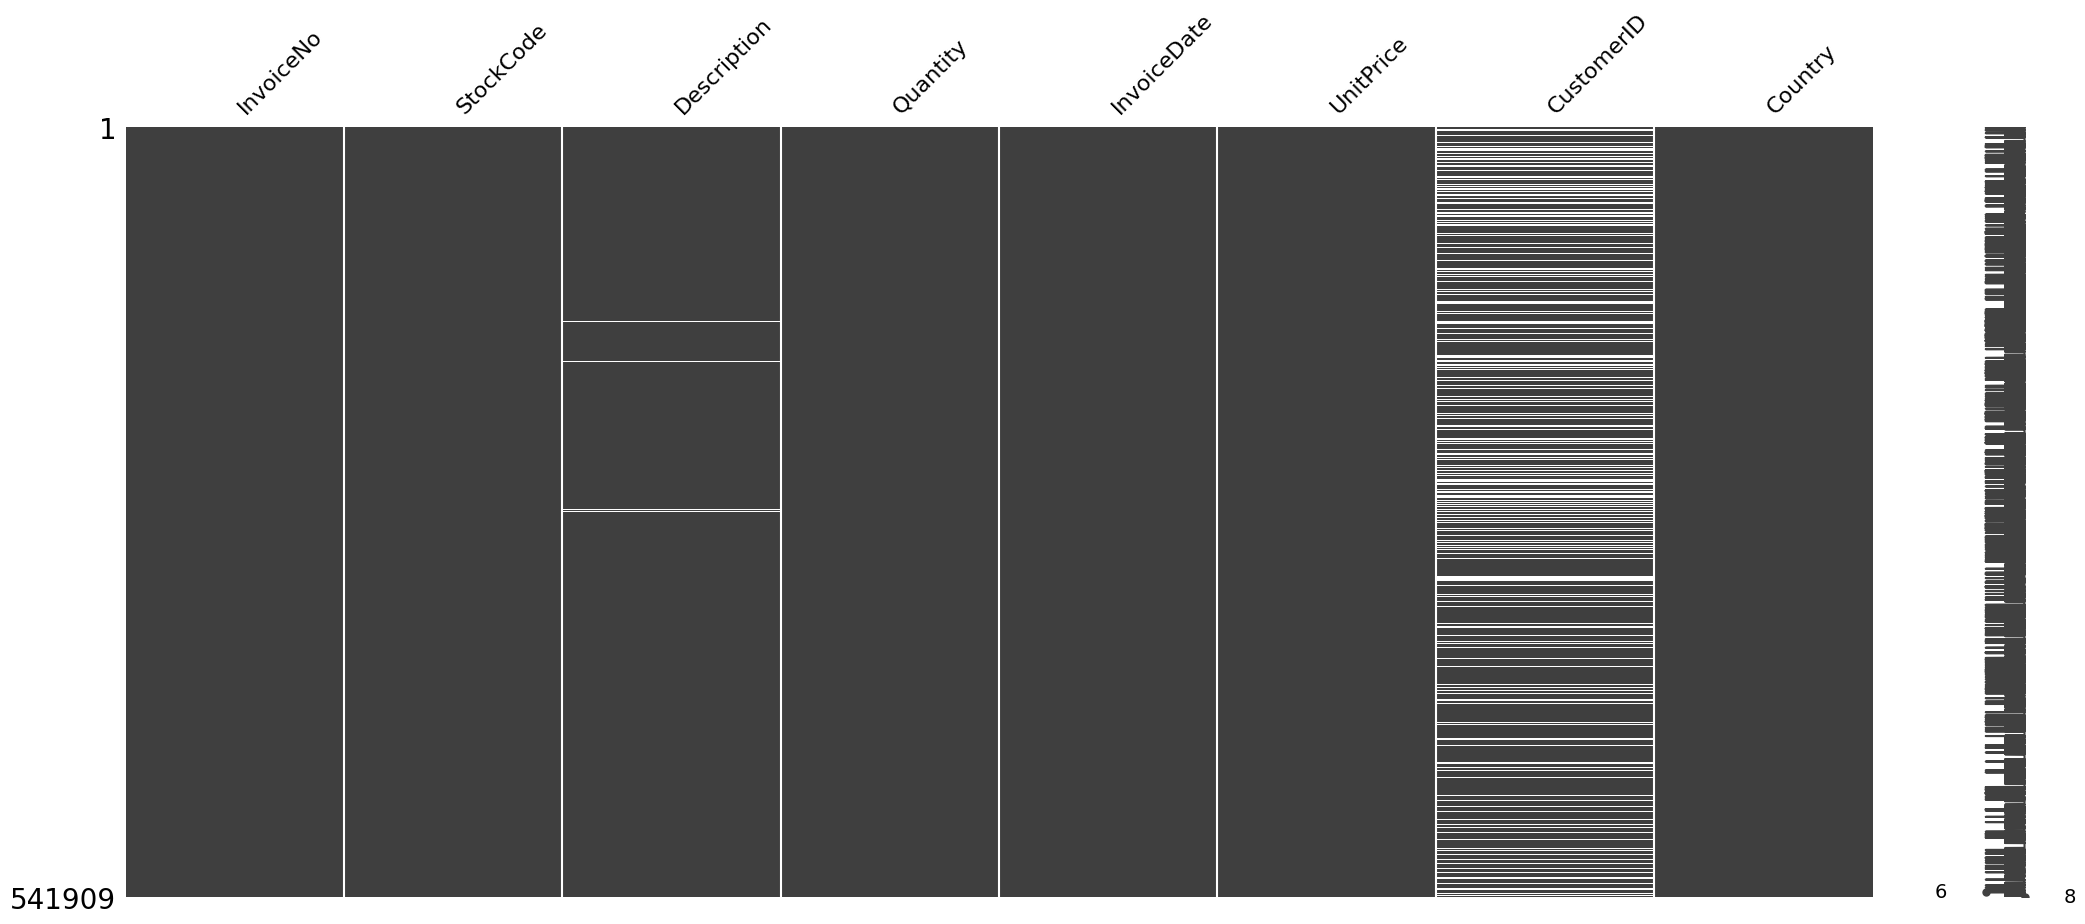

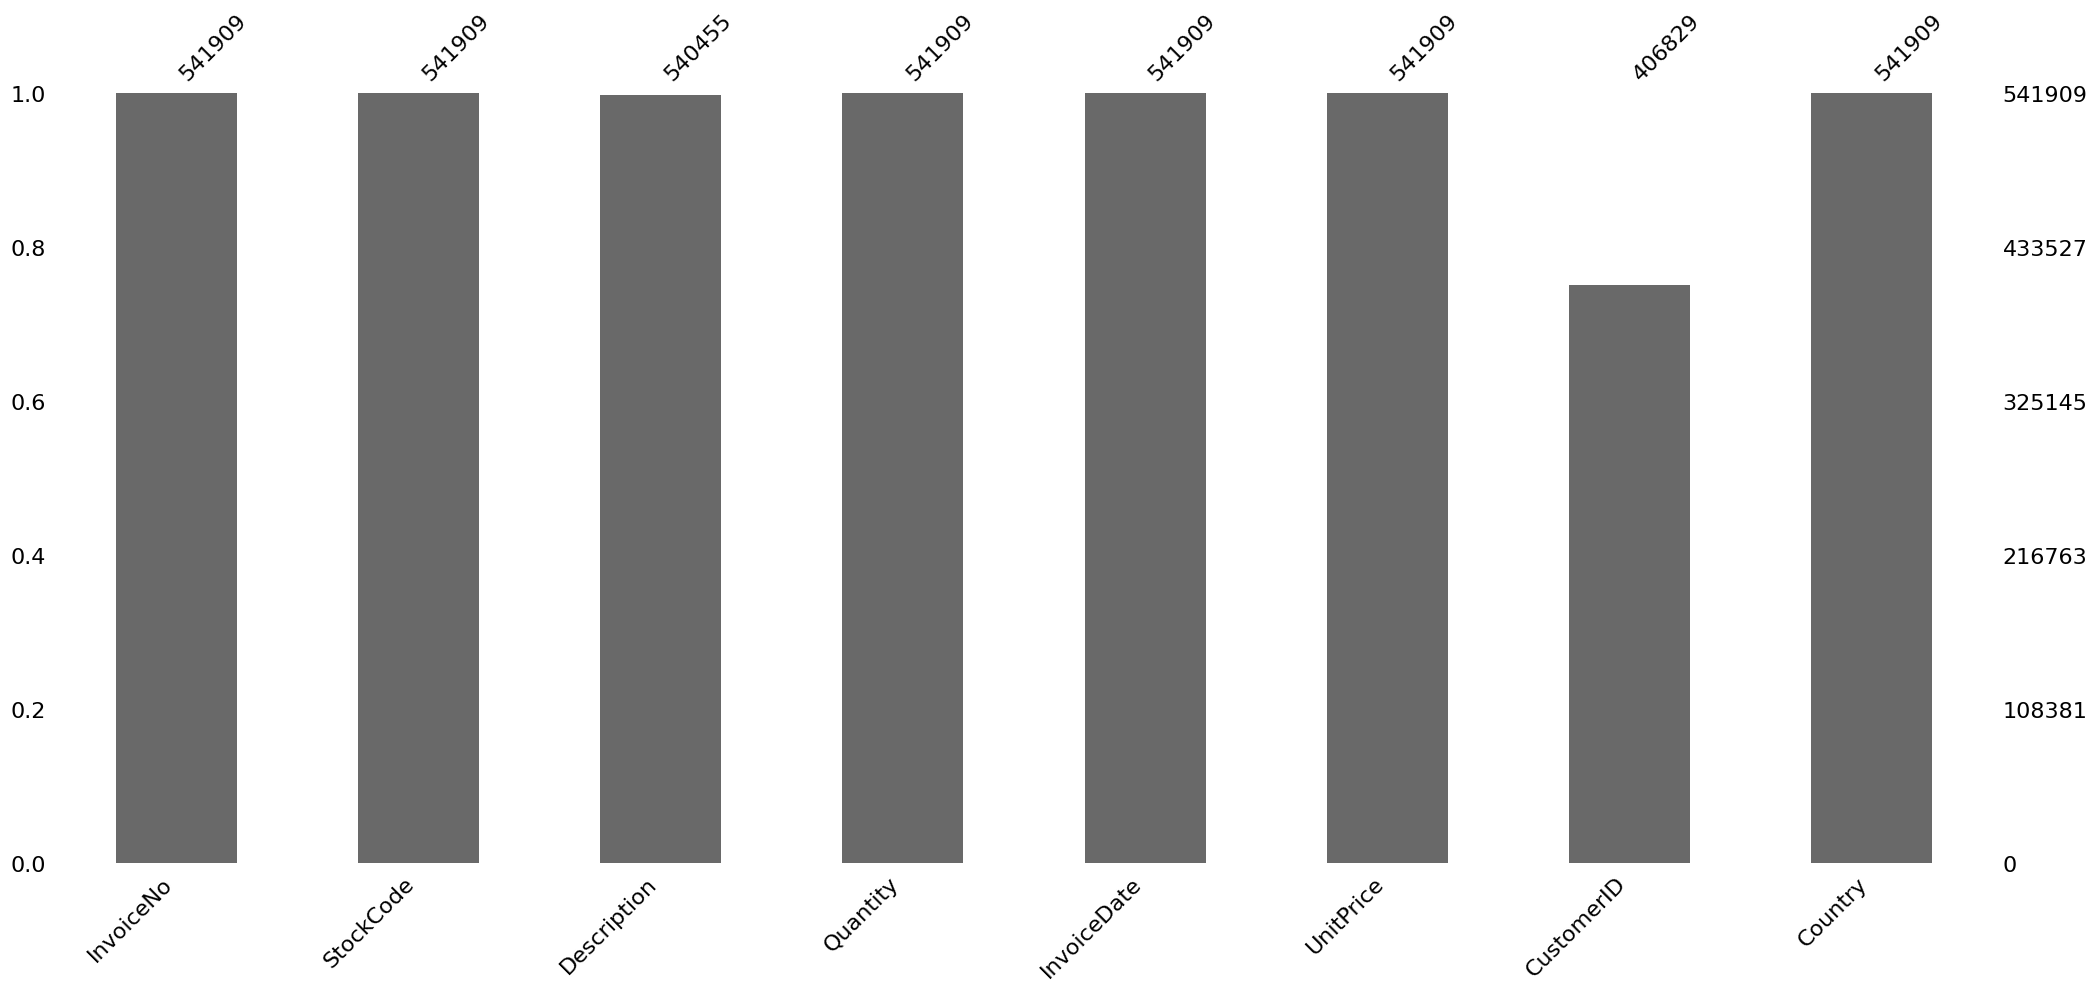

In [6]:
# Missing values count
missing_counts = df.isnull().sum()
print(missing_counts)

# Visualize missing values
msno.matrix(df)
plt.show()
msno.bar(df)
plt.show()

## Data Types and Basic Statistics

Show data types and summary statistics for numeric columns.

In [ ]:
# Data types
print(df.dtypes)

# Summary statistics for numeric columns
print(df.describe())

## Distribution of Numeric Features

Visualize the distributions of Quantity, UnitPrice, and TotalPrice using histograms and boxplots.

In [ ]:
# Create TotalPrice column if not present
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Quantity'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Quantity Distribution')
sns.histplot(df['UnitPrice'], bins=50, ax=axes[1], color='salmon')
axes[1].set_title('UnitPrice Distribution')
sns.histplot(df['TotalPrice'], bins=50, ax=axes[2], color='limegreen')
axes[2].set_title('TotalPrice Distribution')
plt.tight_layout()
plt.show()

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df['Quantity'], ax=axes[0], color='skyblue')
axes[0].set_title('Quantity Boxplot')
sns.boxplot(y=df['UnitPrice'], ax=axes[1], color='salmon')
axes[1].set_title('UnitPrice Boxplot')
sns.boxplot(y=df['TotalPrice'], ax=axes[2], color='limegreen')
axes[2].set_title('TotalPrice Boxplot')
plt.tight_layout()
plt.show()

## CustomerID Analysis

Analyze unique customers, plot the distribution of transactions per customer, and check for missing CustomerIDs.

In [ ]:
# Unique customers
num_customers = df['CustomerID'].nunique()
print('Unique Customers:', num_customers)

# Missing CustomerIDs
missing_cust = df['CustomerID'].isnull().sum()
print('Missing CustomerIDs:', missing_cust)

# Transactions per customer
cust_trans = df['CustomerID'].value_counts()
plt.figure(figsize=(10,5))
sns.histplot(cust_trans, bins=50, color='purple')
plt.title('Distribution of Transactions per Customer')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')
plt.show()

## InvoiceDate Analysis

Plot the number of transactions over time and check for seasonal patterns or trends.

In [ ]:
# Convert InvoiceDate to datetime if not already
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Transactions over time
daily_trans = df.groupby(df['InvoiceDate'].dt.date)['InvoiceNo'].nunique()
plt.figure(figsize=(14,6))
daily_trans.plot()
plt.title('Number of Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

# Monthly trend
monthly_trans = df.groupby(df['InvoiceDate'].dt.to_period('M'))['InvoiceNo'].nunique()
monthly_trans.plot(kind='bar', figsize=(14,6), color='teal')
plt.title('Monthly Transactions Trend')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.show()

## Quantity and UnitPrice Analysis

Visualize the distribution of Quantity and UnitPrice, and identify any anomalies or returns (negative quantities).

In [ ]:
# Distribution of Quantity and UnitPrice
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Quantity'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Quantity Distribution')
sns.histplot(df['UnitPrice'], bins=50, ax=axes[1], color='orange')
axes[1].set_title('UnitPrice Distribution')
plt.tight_layout()
plt.show()

# Negative quantities (returns)
neg_qty = df[df['Quantity'] < 0]
print('Number of returns (negative quantities):', len(neg_qty))
if len(neg_qty) > 0:
    display(neg_qty.head())

## Correlation Analysis

Compute and visualize the correlation matrix for numeric features using a heatmap.

In [ ]:
# Correlation matrix
corr = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## Top Products by Sales

Identify and plot the top-selling products by total sales and frequency.

In [ ]:
# Top products by total sales
top_sales = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top_sales.plot(kind='bar', color='green')
plt.title('Top 10 Products by Total Sales')
plt.ylabel('Total Sales')
plt.xlabel('Product Description')
plt.xticks(rotation=45)
plt.show()

# Top products by frequency
top_freq = df['Description'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_freq.plot(kind='bar', color='blue')
plt.title('Top 10 Products by Frequency')
plt.ylabel('Number of Transactions')
plt.xlabel('Product Description')
plt.xticks(rotation=45)
plt.show()

## RFM Feature Exploration

Calculate Recency, Frequency, and Monetary features for each customer and visualize their distributions.

In [ ]:
# RFM calculation
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm['Recency'], bins=50, ax=axes[0], color='red')
axes[0].set_title('Recency Distribution')
sns.histplot(rfm['Frequency'], bins=50, ax=axes[1], color='blue')
axes[1].set_title('Frequency Distribution')
sns.histplot(rfm['Monetary'], bins=50, ax=axes[2], color='green')
axes[2].set_title('Monetary Distribution')
plt.tight_layout()
plt.show()

## Pairplot of RFM Features

Visualize relationships between Recency, Frequency, and Monetary features using a pairplot.

In [ ]:
# Pairplot of RFM features
sns.pairplot(rfm)
plt.suptitle('Pairplot of RFM Features', y=1.02)
plt.show()

## Outlier Detection

Detect and visualize outliers in Quantity, UnitPrice, and Monetary features using boxplots and scatter plots.

In [ ]:
# Outlier detection for Quantity, UnitPrice, and Monetary
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df['Quantity'], ax=axes[0], color='violet')
axes[0].set_title('Quantity Outliers')
sns.boxplot(y=df['UnitPrice'], ax=axes[1], color='gold')
axes[1].set_title('UnitPrice Outliers')
sns.boxplot(y=rfm['Monetary'], ax=axes[2], color='lightblue')
axes[2].set_title('Monetary Outliers')
plt.tight_layout()
plt.show()

# Scatter plot for Quantity vs TotalPrice to spot outliers
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Quantity'], y=df['TotalPrice'], alpha=0.5)
plt.title('Quantity vs TotalPrice (Outlier Detection)')
plt.xlabel('Quantity')
plt.ylabel('TotalPrice')
plt.show()